In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Olist'in Tahmini Teslimat Süresini (ETA) İyileştirme

👉 `Estimated Time of Arrival (ETA)`, modern e-ticaret hizmetlerinin temel bileşenlerinden biridir. Şirketlerin müşteriye teslimat için tahmini bir tarih göstererek beklentileri yönetmesini sağlar.

🎯 Bu çalışmada, bir siparişin `bekleme süresini tahmin eden` bir model kuracağız.

☑️ Olist'in kendi tahminleri `expected_wait_time` değişkeninde zaten mevcut.

🚀 Hadi daha iyi tahminler yapmaya çalışalım ve bu özetin sonunda şunları karşılaştıralım:
* bizim `estimated_wait_time`
* Olist'in `expected_wait_time`
* teslim edilen her sipariş için gerçek `wait_time`

## `orders` veri setini yükle ve kontrol et

👉 `Order().get_training_data()` (`distance_seller_customer` dahil)

In [2]:
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)

In [3]:
orders.head(3)

,delay_vs_expected,dim_is_five_star,dim_is_one_star,expected_wait_time,freight_value,number_of_items,number_of_sellers,order_id,order_status,price,review_score,wait_time
0,0.0,0,0,15.544063,8.72,1,1,e481f51cbdc54678b7cc49136f2d6af7,delivered,29.99,4,8.436574
1,0.0,0,0,19.137766,22.76,1,1,53cdb2fc8bc7dce0b6741e2150273451,delivered,118.70,4,13.782037
2,0.0,1,0,26.639711,19.22,1,1,47770eb9100c2d0c44946d9cf07ec65d,delivered,159.90,5,9.394213


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95872 entries, 0 to 96360
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   delay_vs_expected   95872 non-null  float64
 1   dim_is_five_star    95872 non-null  int64  
 2   dim_is_one_star     95872 non-null  int64  
 3   expected_wait_time  95872 non-null  float64
 4   freight_value       95872 non-null  float64
 5   number_of_items     95872 non-null  int64  
 6   number_of_sellers   95872 non-null  int64  
 7   order_id            95872 non-null  object 
 8   order_status        95872 non-null  object 
 9   price               95872 non-null  float64
 10  review_score        95872 non-null  int64  
 11  wait_time           95872 non-null  float64
dtypes: float64(5), int64(5), object(2)
memory usage: 9.5+ MB


## Temel Model - Olist'in mevcut ETA modeli

🐣  Optimize etmek istediğimiz temel seviye (baseline) nedir ❓

👉 Olist'in `expected_wait_time` değeri ile gerçek `wait_time` arasındaki fark

📈 İlgili histogramlarını çiz

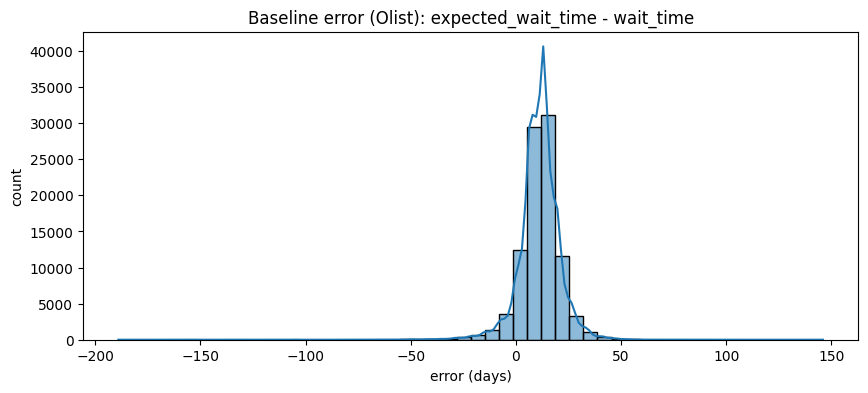

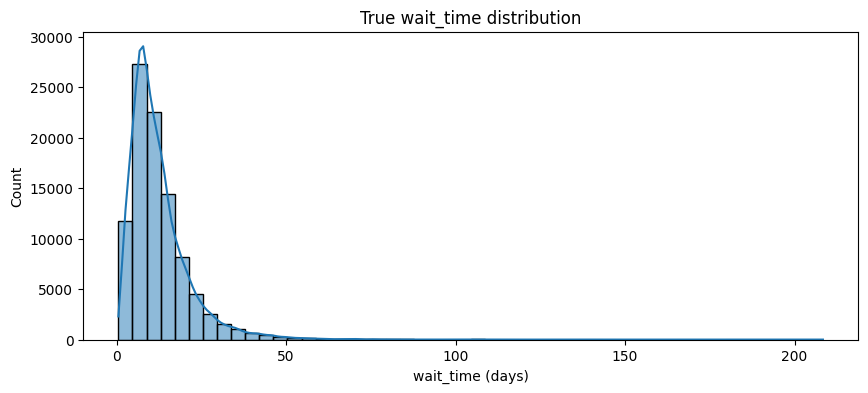

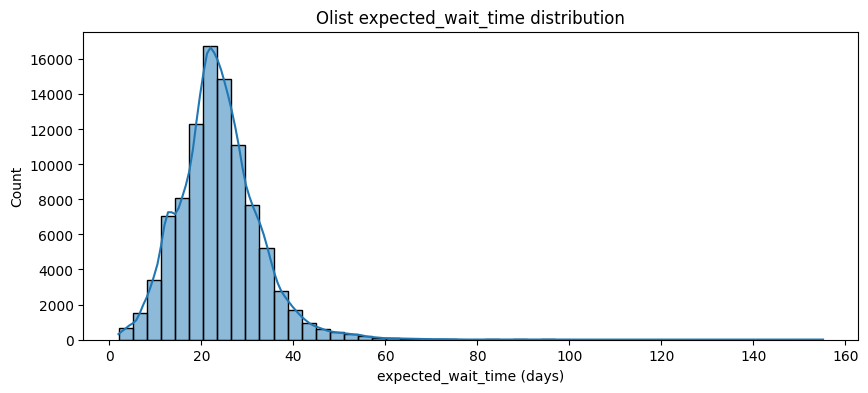

In [5]:
# Baseline error: Olist expected - true
baseline_error = orders["expected_wait_time"] - orders["wait_time"]

plt.figure(figsize=(10,4))
sns.histplot(baseline_error, bins=50, kde=True)
plt.title("Baseline error (Olist): expected_wait_time - wait_time")
plt.xlabel("error (days)")
plt.ylabel("count")
plt.show()

# İstersen beklenen ve gerçek dağılımlar:
plt.figure(figsize=(10,4))
sns.histplot(orders["wait_time"], bins=50, kde=True)
plt.title("True wait_time distribution")
plt.xlabel("wait_time (days)")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(orders["expected_wait_time"], bins=50, kde=True)
plt.title("Olist expected_wait_time distribution")
plt.xlabel("expected_wait_time (days)")
plt.show()

👉 Medyan bekleme süresi nedir? Medyan beklenen bekleme süresi nedir?

In [6]:
median_wait_time = orders["wait_time"].median()
median_expected_wait_time = orders["expected_wait_time"].median()

print("Median wait_time:", median_wait_time)
print("Median expected_wait_time:", median_expected_wait_time)

Median wait_time: 10.203726851851851
Median expected_wait_time: 23.230555555555554


👉 Temel RMSE'yi hesapla

ℹ️ Burada ele alınan hatalar, Olist'in bekleme süresi tahminindeki sapmalarıdır.

In [7]:
baseline_RMSE = np.sqrt(np.mean((orders["expected_wait_time"] - orders["wait_time"])**2))
baseline_RMSE

15.110701386210625

## OLS çok değişkenli model

👉 Bu sefer `statsmodel.api.OLS` yöntemini kullanarak bir OLS modeli oluşturacağız.

(`statsmodel.formula.api.ols` yerine)

### X özellikleri ve Y hedefi ile veri setini hazırla

In [8]:
orders.columns.tolist()

['delay_vs_expected',
 'dim_is_five_star',
 'dim_is_one_star',
 'expected_wait_time',
 'freight_value',
 'number_of_items',
 'number_of_sellers',
 'order_id',
 'order_status',
 'price',
 'review_score',
 'wait_time']

In [9]:
features = [
    "number_of_items",
    "number_of_sellers",
    "price",
    "freight_value",
    "review_score",
    "dim_is_one_star",
    "dim_is_five_star"
]

X = orders[features].copy()
y = orders["wait_time"].copy()

X.head(), y.head()

(   number_of_items  number_of_sellers   price  freight_value  review_score  \
 0                1                  1   29.99           8.72             4   
 1                1                  1  118.70          22.76             4   
 2                1                  1  159.90          19.22             5   
 3                1                  1   45.00          27.20             5   
 4                1                  1   19.90           8.72             5   
 
    dim_is_one_star  dim_is_five_star  
 0                0                 0  
 1                0                 0  
 2                0                 1  
 3                0                 1  
 4                0                 1  ,
 0     8.436574
 1    13.782037
 2     9.394213
 3    13.208750
 4     2.873877
 Name: wait_time, dtype: float64)

⚖️ OLS sonucunda elde edilecek regresyon katsayılarını karşılaştırabilmek için X'in her bir özelliğini standartlaştır (`z-score`):

In [10]:
X_std = X.copy()

for f in X_std.columns:
    mu_f = X_std[f].mean()
    sigma_f = X_std[f].std()
    X_std[f] = (X_std[f] - mu_f) / sigma_f

X_std.describe()

,number_of_items,number_of_sellers,price,freight_value,review_score,dim_is_one_star,dim_is_five_star
count,9.587200e+04,9.587200e+04,9.587200e+04,9.587200e+04,9.587200e+04,9.587200e+04,9.587200e+04
mean,-1.129493e-16,2.902292e-16,1.259933e-17,-1.422983e-17,1.497096e-16,8.122860e-17,-5.832747e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.645951e-01,-1.125444e-01,-6.541191e-01,-1.057298e+00,-2.455433e+00,-3.289644e-01,-1.204841e+00
25%,-2.645951e-01,-1.125444e-01,-4.371915e-01,-4.150170e-01,-1.210083e-01,-3.289644e-01,-1.204841e+00
50%,-2.645951e-01,-1.125444e-01,-2.441477e-01,-2.597913e-01,6.571332e-01,-3.289644e-01,8.299767e-01
75%,-2.645951e-01,-1.125444e-01,6.359577e-02,5.763123e-02,6.571332e-01,-3.289644e-01,8.299767e-01
max,3.705941e+01,3.224085e+01,6.405892e+01,8.236302e+01,6.571332e-01,3.039811e+00,8.299767e-01


In [11]:
# Check how different is it from the "formula" in statsmodel
import patsy

# Bu repoda distance_seller_customer yok, onun yerine elimizdeki feature'ları kullanıyoruz:
patsy.dmatrix('price + freight_value + number_of_items + number_of_sellers + review_score + dim_is_one_star + dim_is_five_star', orders)

DesignMatrix with shape (95872, 8)
  Columns:
    ['Intercept',
     'price',
     'freight_value',
     'number_of_items',
     'number_of_sellers',
     'review_score',
     'dim_is_one_star',
     'dim_is_five_star']
  Terms:
    'Intercept' (column 0)
    'price' (column 1)
    'freight_value' (column 2)
    'number_of_items' (column 3)
    'number_of_sellers' (column 4)
    'review_score' (column 5)
    'dim_is_one_star' (column 6)
    'dim_is_five_star' (column 7)
  (to view full data, use np.asarray(this_obj))

⚠️ Bu `statsmodel.api.OLS` ile, özellikler veri setine her zaman sabit bir "intercept" (kesme) eklememiz gerekir:

In [12]:
X_std["constant"] = 1
X_std.head()

,number_of_items,number_of_sellers,price,freight_value,review_score,dim_is_one_star,dim_is_five_star,constant
0,-0.264595,-0.112544,-0.513802,-0.652038,-0.121008,-0.328964,-1.204841,1
1,-0.264595,-0.112544,-0.086640,0.000467,-0.121008,-0.328964,-1.204841,1
2,-0.264595,-0.112544,0.111748,-0.164053,0.657133,-0.328964,0.829977,1
3,-0.264595,-0.112544,-0.441525,0.206815,0.657133,-0.328964,0.829977,1
4,-0.264595,-0.112544,-0.562388,-0.652038,0.657133,-0.328964,0.829977,1


### `statsmodels` ile OLS'i çalıştır ve `summary` çıktısını yazdır

In [13]:
model = sm.OLS(y, X_std).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              wait_time   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     2561.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:19:27   Log-Likelihood:            -3.4320e+05
No. Observations:               95872   AIC:                         6.864e+05
Df Residuals:                   95864   BIC:                         6.865e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
number_of_items      -1.2619      0.032    -38.967      0.000      -1.325      -1.198
number_of_sellers    -0.6695      0.029    -22.773      0.000      -0.727      -0.612
price                -0.2029      0.031     -6.598      0.000      -0.263      -0.143
freight_value         2.0054      0.034     59.290      0.000       1.939       2.072
review_score         -2.8392      0.097    -29.232      0.000      -3.030      -2.649
dim_is_one_star       0.7867      0.064     12.198      0.000       0.660       0.913
dim_is_five_star      0.3232      0.062      5.190      0.000       0.201       0.445
constant             12.5134      0.028    446.453      0.000      12.459      12.568
==============================================================================
Omnibus:                    82946.483   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          9264065.364
Skew:                           3.648   Prob(JB):                         0.00
Kurtosis:                      50.601   Cond. No.                         7.04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## OLS modelinin performansını kontrol et

### Uyum iyiliği (goodness of fit)

👉 En iyi tahminleri kim yapıyor: sen mi, Olist mi?

- Tahminlerini hesapla ve `y_pred` değişkeninde sakla

- Şunları da saklayabilirsin:
    - Olist'in tahminlerini `y_expected_olist` değişkeninde
    - gerçek bekleme sürelerini `y_true` değişkeninde


In [14]:
y_true = y
y_expected_olist = orders["expected_wait_time"]
y_pred = model.predict(X_std)

y_pred[:5]

0    11.414777
1    12.636620
2    10.714728
3    11.570755
4     9.872938
dtype: float64

📈 `y_pred`, `y_expected_olist` ve `y_true` değerlerini aynı grafikte çiz.

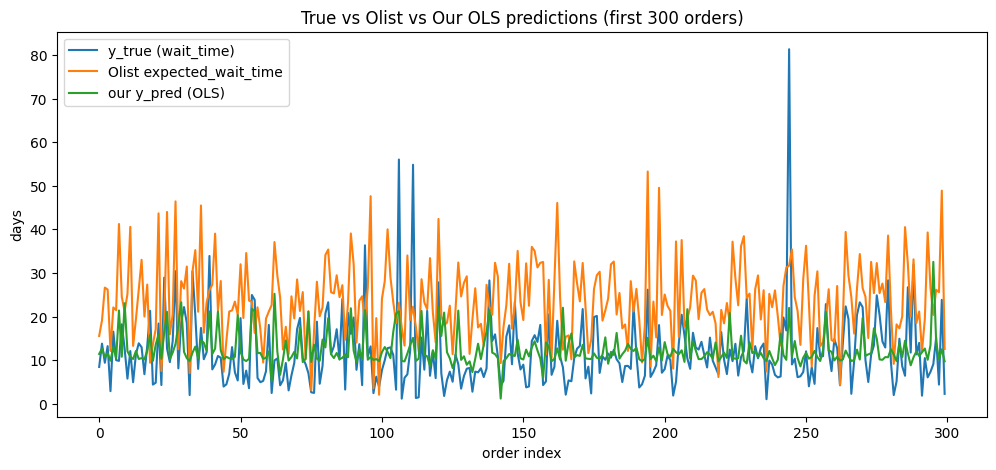

In [15]:
n_plot = 300

plt.figure(figsize=(12,5))
plt.plot(y_true.iloc[:n_plot].values, label="y_true (wait_time)")
plt.plot(y_expected_olist.iloc[:n_plot].values, label="Olist expected_wait_time")
plt.plot(pd.Series(y_pred).iloc[:n_plot].values, label="our y_pred (OLS)")
plt.title("True vs Olist vs Our OLS predictions (first 300 orders)")
plt.xlabel("order index")
plt.ylabel("days")
plt.legend()
plt.show()

👉 Artık hatalar *senin* hataların olacak şekilde RMSE'yi hesapla!

In [16]:
rmse_lewagon = np.sqrt(np.mean((y_pred - y_true)**2))
rmse_lewagon

8.678187511612355

Hatırlatma olarak, Olist'in RMSE'si şuna eşitti: 👇

In [17]:
baseline_RMSE

15.110701386210625

😏 Gerçekten Olist'in Veri Bilimcilerini yendik mi? Pek de öyle diyemeyiz!

- Birçok e-ticaret ve teslimat servisinde ETA çoğu zaman yüksek tahmin edilir...
- Müşteriler siparişlerini beklenenden erken aldıklarında memnun olma olasılıkları daha yüksektir!

### Kısmi korelasyonlar

👉 `sm.graphics.plot_partregress_grid` ile kısmi korelasyonları görselleştir

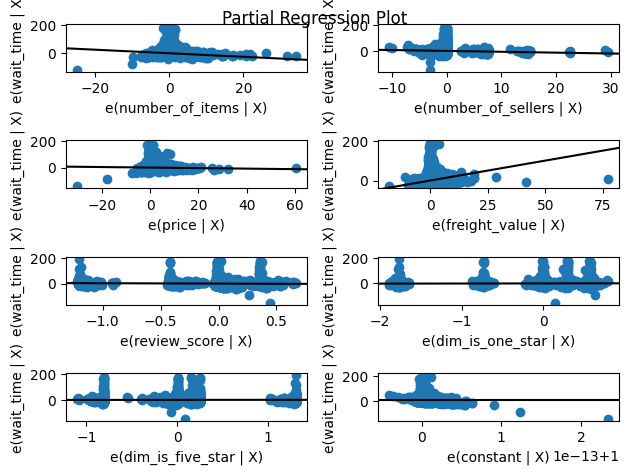

In [18]:
sm.graphics.plot_partregress_grid(model)
plt.show()

**Bu grafikleri nasıl okuruz?**

👉 Örneğin sol alt köşedeki grafiğe odaklanalım:

<u>`wait_time` ile `distance` arasındaki kısmi regresyon</u>

- Her nokta veri setimizdeki bir sipariştir


- `y-ekseni`: `distance` hariç tüm özellikleri kullanarak elde edilen `wait_time` artık (residual) değerleri

    - Bu artıklar, `distance` olmadan açıklanamayan `wait_time` hakkındaki kalan bilgiyi içerir


- `x-ekseni`: diğer tüm özellikler (price, freight_value, vb...) kullanılarak `distance` tahmininin artık (residual) değerleri
    - Bu artıklar, modeldeki diğer özelliklerle zaten açıklanmayan ve `distance` değişkeninin getirdiği yeni bilgiyi içerir.


### Çıkarımsal koşullar

⚠️ Artık (residual) değerlerini kontrol et. Normal dağılıma uyuyorlar mı?

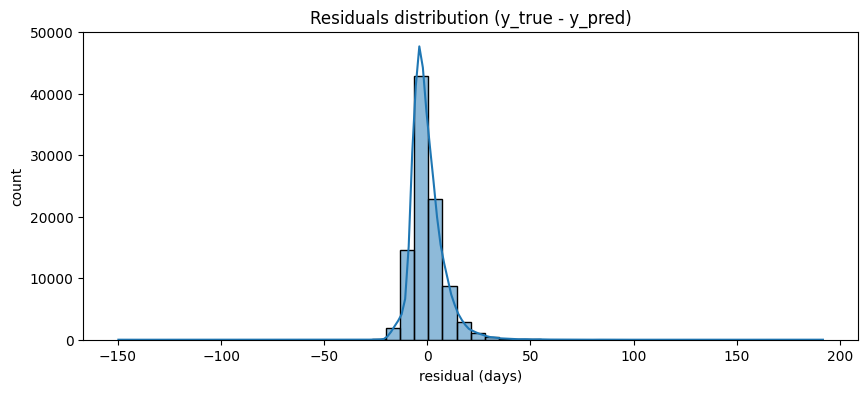

In [19]:
residuals_lewagon = y_true - y_pred

plt.figure(figsize=(10,4))
sns.histplot(residuals_lewagon, bins=50, kde=True)
plt.title("Residuals distribution (y_true - y_pred)")
plt.xlabel("residual (days)")
plt.ylabel("count")
plt.show()

🎁 Bir dağılımın Gauss (normal) olup olmadığını daha hassas görselleştirmenin bir yolu <a href="https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html">**`QQplot`**</a>'tur.

📈 Aşağıya artık (residual) değerlerinin QQplot'unu çiz.

💡 QQ plot ile az önce çizilen yoğunluk (density) grafiği arasındaki ilişkiyi mutlaka anla..

📚 <a href="https://stats.stackexchange.com/questions/101274/how-to-interpret-a-qq-plot">Stats.StackExchange.com - QQplot yorumlama</a>

- `x-axis` : bir Gauss dağılımının teorik kantilleri
- `y-axis`: sıralanmış değişkenin kantilleri

💡 Eğer <span style="color:blue">mavi</span> noktalar, özdeşlik (identity) fonksiyonu olan <span style="color:red">kırmızı çizgi</span> üzerinde hizalanıyorsa, değişken Gauss dağılımına sahiptir!

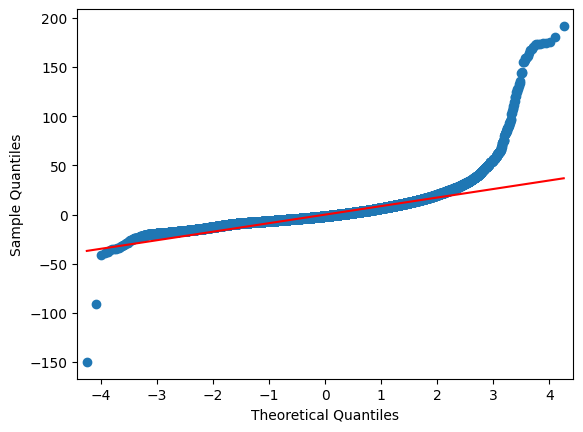

In [20]:
sm.qqplot(residuals_lewagon, line='s');

#### Bazı QQplot örnekleri:

QQ plot'ların nasıl çizildiğini anlamak için aşağıdaki hücreleri çalıştır:

In [21]:
from scipy import stats
stats.norm.rvs(0,1)

0.4259056633572527

(-4.461654433798692, 10.0)

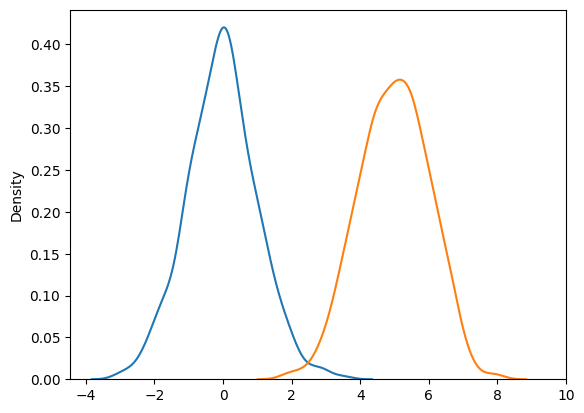

In [22]:
# lets check QQ plots with our own distributions
from scipy import stats

norm_1 = [stats.norm.rvs(0,1) for x in range(1000)]
norm_2 = [stats.norm.rvs(5,1) for x in range(1000)]

sns.kdeplot(norm_1)
sns.kdeplot(norm_2)
plt.xlim(right=10)

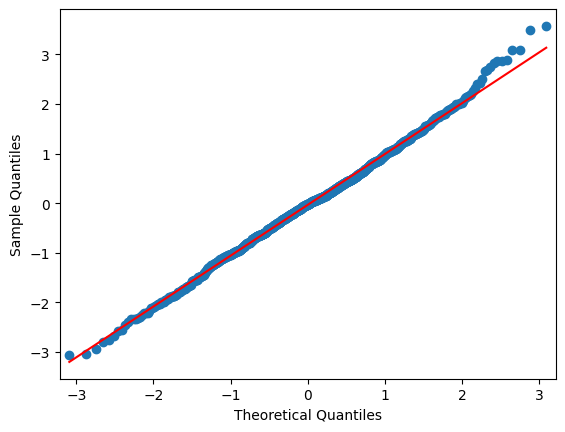

In [23]:
sm.qqplot(np.asarray(norm_1), line='s');

(-5.569405066812424, 10.0)

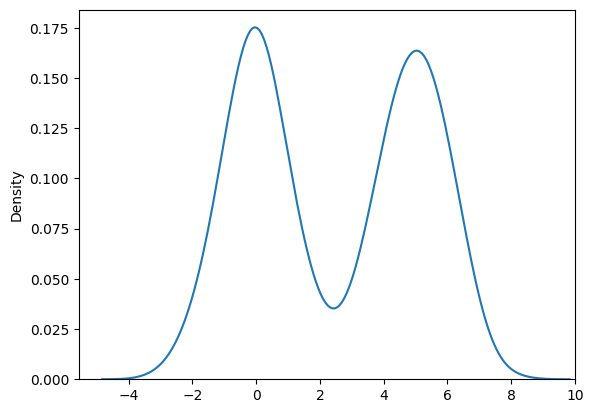

In [24]:
bimodal = norm_1 + norm_2
sns.kdeplot(bimodal)
plt.xlim(right=10)

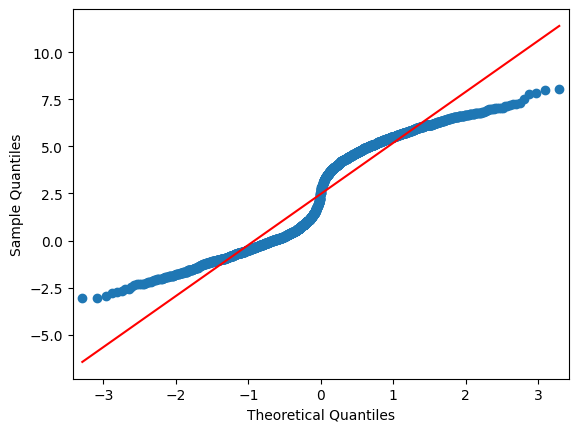

In [25]:
sm.qqplot(np.asarray(bimodal), line='s');

<img src="https://wagon-public-datasets.s3.amazonaws.com/04-Decision-Science/03-Linear-Regression/qq_plot_interpretation.png" width=400>

#### Rastgele olmayan bir desen yakalayıp yakalayamayacağımızı görmek için artıklar (residuals) vs. uyumlanan (fitted) değerleri kontrol et

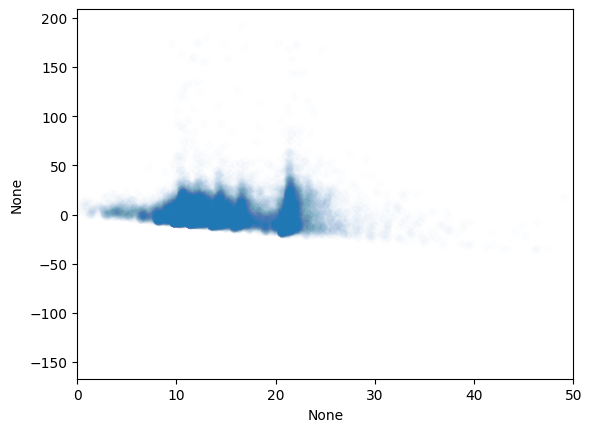

In [26]:
sns.scatterplot(x=y_pred, y=residuals_lewagon, alpha=0.01)
plt.xlim(xmin=0, xmax=50)
plt.show()

## Daha Fazla Özellik? (Opsiyonel)

Burada ürün detaylarından (boyut, kategori vb.) ek özellikler ekleyebiliriz.

### Her siparişle ilişkili ürün detaylarını ekle (ürün boyutları toplamı, ağırlıklar toplamı vb.)

In [27]:
from olist.data import Olist
data = Olist().get_data()
products = data['products']
order_items = data['order_items']

In [28]:
order_items_products = (
    order_items.groupby(["order_id", "product_id"], as_index=False)
    .agg({"order_item_id": "count"})
    .rename(columns={"order_item_id": "order_item_count"})
    .merge(products.drop(["product_category_name"], axis=1), on="product_id")
)
order_items_products

,order_id,product_id,order_item_count,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,1,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,1,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...
102420,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,1,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
102421,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,1,31.0,232.0,1.0,8950.0,45.0,26.0,38.0
102422,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,1,43.0,869.0,1.0,967.0,21.0,24.0,19.0
102423,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,1,56.0,1306.0,1.0,100.0,20.0,20.0,20.0


In [29]:
# Since we want the sum of product weights per order from our new DataFrame, we need to multiply weight by product count
order_items_products['product_weight_g'] = order_items_products['product_weight_g'] *  order_items_products['order_item_count']

order_items_features = order_items_products.groupby("order_id", as_index=False).agg(
    {
        "product_weight_g": "sum",
        "product_length_cm": "max",
        "product_height_cm": "max",
        "product_width_cm": "max",
    }).rename(columns={
        "product_weight_g": "product_weight_g_sum",
        "product_length_cm": "product_length_cm_max",
        "product_height_cm": "product_height_cm_max",
        "product_width_cm": "product_width_cm_max",
    })
order_items_features

,order_id,product_weight_g_sum,product_length_cm_max,product_height_cm_max,product_width_cm_max
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,35.0,40.0,30.0
...,...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,10150.0,89.0,15.0,40.0
98662,fffcd46ef2263f404302a634eb57f7eb,8950.0,45.0,26.0,38.0
98663,fffce4705a9662cd70adb13d4a31832d,967.0,21.0,24.0,19.0
98664,fffe18544ffabc95dfada21779c9644f,100.0,20.0,20.0,20.0


In [30]:
orders_with_details = orders.merge(order_items_features, on="order_id", how="left").dropna()

In [31]:
X2 = orders_with_details[[
        "number_of_items",
        "number_of_sellers",
        "price",
        "freight_value",
        "distance_seller_customer",
        "product_weight_g_sum",
        "product_length_cm_max",
        "product_height_cm_max",
        "product_width_cm_max"]].copy()
y2 = orders_with_details["wait_time"].copy()

KeyError: "['distance_seller_customer'] not in index"

In [ ]:
# standardize (z-normalize) each features of X to compare coefficients
for f in X2.columns:
    mu = X2[f].mean()
    sigma = X2[f].std()
    X2[f] = X2[f].map(lambda x: (x - mu) / sigma)

In [ ]:
X2['constant'] = 1

In [ ]:
model2 = sm.OLS(y2, X2).fit()

In [ ]:
model2.summary()